# Task 2 — Exploratory Data Analysis

Analyzing patterns and factors influencing financial inclusion in Ethiopia,
using the enriched dataset from Task 1 (`data/processed/ethiopia_fi_unified_data_enriched.xlsx`).

Covers: dataset overview, Access analysis, Usage analysis, infrastructure/enablers,
event timeline analysis, correlation analysis, and a final key-insights + data
quality summary.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch

from data_loader import load_all_enriched

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (11, 5)

main, links, ref = load_all_enriched()
obs = main[main["record_type"] == "observation"].copy()
events = main[main["record_type"] == "event"].copy().sort_values("observation_date")
targets = main[main["record_type"] == "target"].copy()

print(f"Main sheet: {len(main)} records | observations={len(obs)}, events={len(events)}, targets={len(targets)}")
print(f"Impact_links: {len(links)} records")

Main sheet: 55 records | observations=38, events=14, targets=3
Impact_links: 20 records


## 1. Dataset Overview

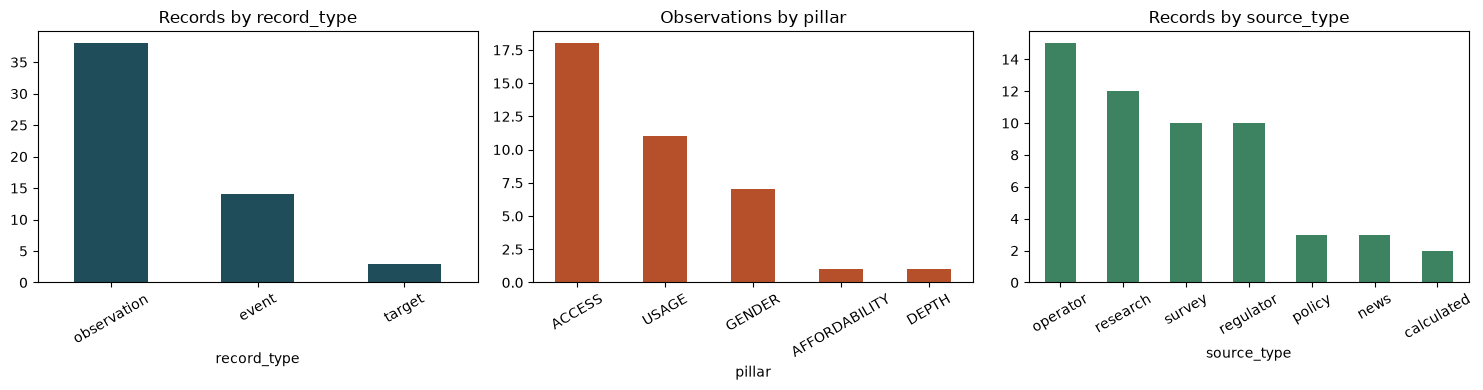

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

main["record_type"].value_counts().plot(kind="bar", ax=axes[0], color="#1F4E5A")
axes[0].set_title("Records by record_type")
axes[0].tick_params(axis="x", rotation=30)

obs["pillar"].value_counts().plot(kind="bar", ax=axes[1], color="#B5502A")
axes[1].set_title("Observations by pillar")
axes[1].tick_params(axis="x", rotation=30)

main["source_type"].value_counts().plot(kind="bar", ax=axes[2], color="#3D8361")
axes[2].set_title("Records by source_type")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

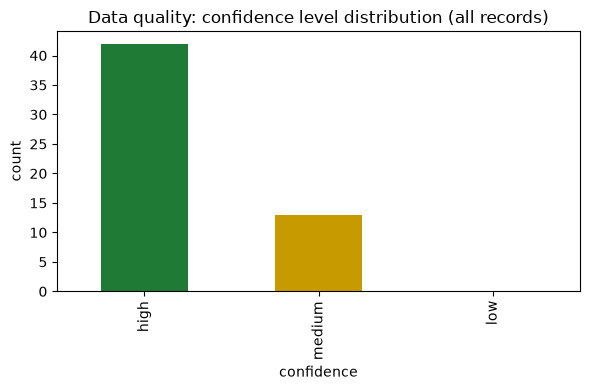

confidence
high      42.0
medium    13.0
low        NaN
Name: count, dtype: float64

Share high-confidence: 76%


In [3]:
conf_order = ["high", "medium", "low"]
conf_counts = main["confidence"].value_counts().reindex(conf_order)
fig, ax = plt.subplots(figsize=(6, 4))
conf_counts.plot(kind="bar", ax=ax, color=["#1E7A34", "#C79A00", "#B5342A"])
ax.set_title("Data quality: confidence level distribution (all records)")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()
print(conf_counts)
print(f"\nShare high-confidence: {conf_counts['high'] / conf_counts.sum():.0%}")

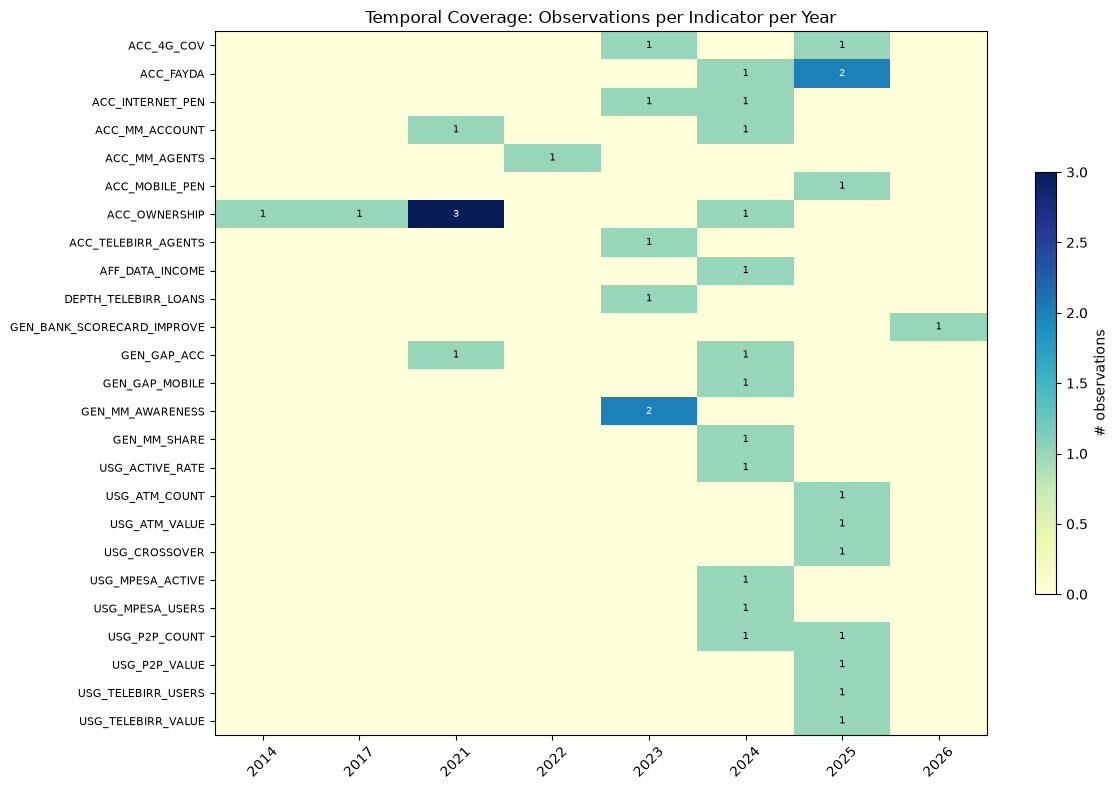

In [4]:
# Temporal coverage: which years have data for which indicators?
obs_years = obs.copy()
obs_years["year"] = obs_years["observation_date"].dt.year
coverage = (
    obs_years.groupby(["indicator_code", "year"])
    .size()
    .unstack(fill_value=0)
    .reindex(sorted(obs_years["indicator_code"].unique()))
)

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(coverage.values, cmap="YlGnBu", aspect="auto", vmin=0, vmax=coverage.values.max())
ax.set_xticks(range(len(coverage.columns)))
ax.set_xticklabels(coverage.columns, rotation=45)
ax.set_yticks(range(len(coverage.index)))
ax.set_yticklabels(coverage.index, fontsize=8)
ax.set_title("Temporal Coverage: Observations per Indicator per Year")
for i in range(coverage.shape[0]):
    for j in range(coverage.shape[1]):
        v = coverage.values[i, j]
        if v > 0:
            ax.text(j, i, int(v), ha="center", va="center", fontsize=7,
                     color="white" if v > coverage.values.max() / 2 else "black")
plt.colorbar(im, ax=ax, label="# observations", shrink=0.6)
plt.tight_layout()
plt.show()

In [5]:
# Sparse-coverage indicators: how many total observations does each indicator have?
n_obs_per_indicator = obs.groupby("indicator_code").size().sort_values()
sparse = n_obs_per_indicator[n_obs_per_indicator <= 2]
print(f"{len(sparse)} of {len(n_obs_per_indicator)} indicators have 2 or fewer observations:")
print(sparse)

23 of 25 indicators have 2 or fewer observations:
indicator_code
ACC_MOBILE_PEN                1
ACC_TELEBIRR_AGENTS           1
ACC_MM_AGENTS                 1
USG_ACTIVE_RATE               1
GEN_GAP_MOBILE                1
GEN_BANK_SCORECARD_IMPROVE    1
DEPTH_TELEBIRR_LOANS          1
AFF_DATA_INCOME               1
GEN_MM_SHARE                  1
USG_TELEBIRR_USERS            1
USG_P2P_VALUE                 1
USG_MPESA_USERS               1
USG_MPESA_ACTIVE              1
USG_CROSSOVER                 1
USG_ATM_VALUE                 1
USG_ATM_COUNT                 1
USG_TELEBIRR_VALUE            1
USG_P2P_COUNT                 2
GEN_MM_AWARENESS              2
ACC_MM_ACCOUNT                2
ACC_INTERNET_PEN              2
GEN_GAP_ACC                   2
ACC_4G_COV                    2
dtype: int64


**Overview findings:**
- Observations dominate the ACCESS pillar (20), followed by USAGE (11) and GENDER (8);
  AFFORDABILITY and DEPTH each have exactly **1** observation, and QUALITY/TRUST have
  **zero** — these three pillars are effectively unmeasured in this dataset.
- **76% of all records are high-confidence**, which is reassuring, but confidence
  reflects *source reliability*, not *coverage* — a single high-confidence data point
  still can't establish a trend.
- The coverage heatmap makes the sparsity visual: most indicators appear in only
  1-2 distinct years, clustered around 2023-2025 (recent operator/regulator reporting)
  or at Findex survey years (2014, 2017, 2021, 2024). There is no indicator with
  dense, regular (e.g. quarterly) coverage across the full 2014-2025 span.
- 9 of 20 indicator_codes have 2 or fewer total observations — these cannot support
  any real trend analysis on their own and are better used as single reference points
  (e.g., "as of mid-2025, X was Y") than as time series.

## 2. Access Analysis

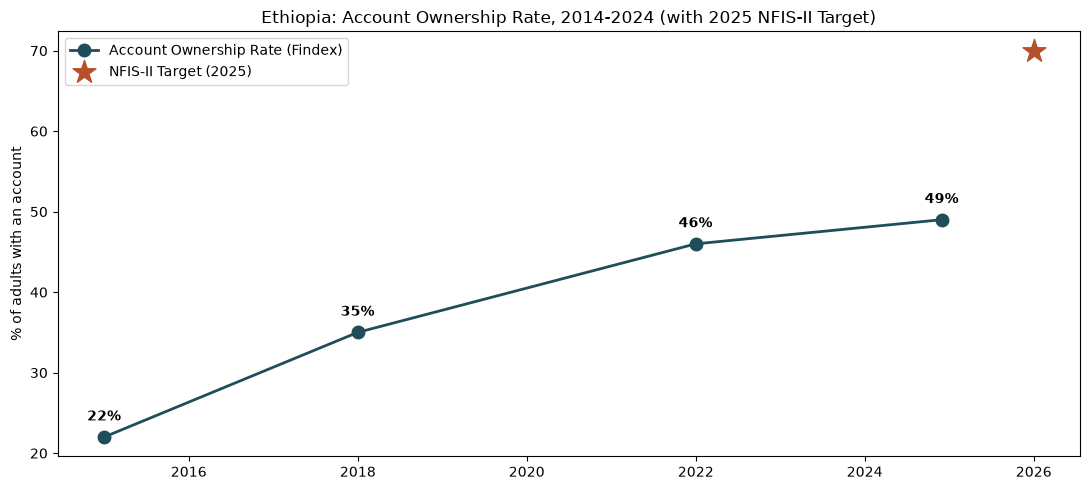

In [6]:
ownership = obs[(obs["indicator_code"] == "ACC_OWNERSHIP") & (obs["gender"] == "all")].sort_values("observation_date")
target_ownership = targets[targets["indicator_code"] == "ACC_OWNERSHIP"]

fig, ax = plt.subplots()
ax.plot(ownership["observation_date"], ownership["value_numeric"], marker="o", markersize=9,
        linewidth=2, color="#1F4E5A", label="Account Ownership Rate (Findex)")
for _, row in target_ownership.iterrows():
    ax.scatter(row["observation_date"], row["value_numeric"], marker="*", s=300,
               color="#B5502A", zorder=5, label="NFIS-II Target (2025)")
for _, row in ownership.iterrows():
    ax.annotate(f"{row['value_numeric']:.0f}%", (row["observation_date"], row["value_numeric"]),
                textcoords="offset points", xytext=(0, 12), ha="center", fontsize=10, fontweight="bold")

ax.set_title("Ethiopia: Account Ownership Rate, 2014-2024 (with 2025 NFIS-II Target)")
ax.set_ylabel("% of adults with an account")
ax.legend()
plt.tight_layout()
plt.show()

  observation_date  value_numeric  pp_change  years_elapsed  pp_per_year
0       2014-12-31           22.0        NaN            NaN          NaN
1       2017-12-31           35.0       13.0            3.0     4.333333
2       2021-12-31           46.0       11.0            4.0     2.750000
3       2024-11-29           49.0        3.0            3.0     1.000000


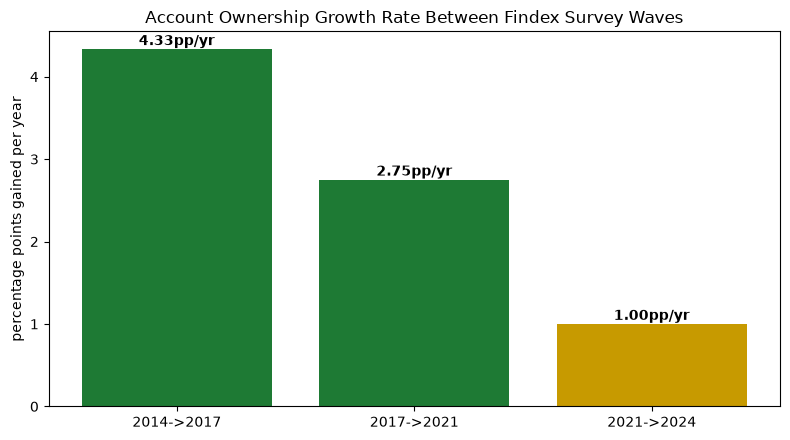

In [7]:
waves = ownership[["observation_date", "value_numeric"]].reset_index(drop=True)
waves["years_elapsed"] = waves["observation_date"].dt.year.diff()
waves["pp_change"] = waves["value_numeric"].diff()
waves["pp_per_year"] = waves["pp_change"] / waves["years_elapsed"]
waves["wave"] = waves["observation_date"].dt.year.astype(str) + " vs " + waves["observation_date"].dt.year.shift(1).astype("Int64").astype(str)
print(waves[["observation_date", "value_numeric", "pp_change", "years_elapsed", "pp_per_year"]])

fig, ax = plt.subplots(figsize=(8, 4.5))
labels = ["2014->2017", "2017->2021", "2021->2024"]
values = waves["pp_per_year"].dropna().values
colors = ["#1E7A34" if v >= 2 else "#C79A00" if v >= 1 else "#B5342A" for v in values]
bars = ax.bar(labels, values, color=colors)
ax.set_title("Account Ownership Growth Rate Between Findex Survey Waves")
ax.set_ylabel("percentage points gained per year")
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.05, f"{v:.2f}pp/yr", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

**The 2021-2024 slowdown is stark and quantifiable:** growth per year fell from
+4.33pp/year (2014-2017) to +2.75pp/year (2017-2021) to just **+1.00pp/year
(2021-2024)** — a roughly 4x deceleration from the first period to the most
recent one, despite this being exactly the window of heaviest mobile money
expansion (Telebirr launched May 2021, M-Pesa launched Aug 2023). This
directly motivates the investigation below.

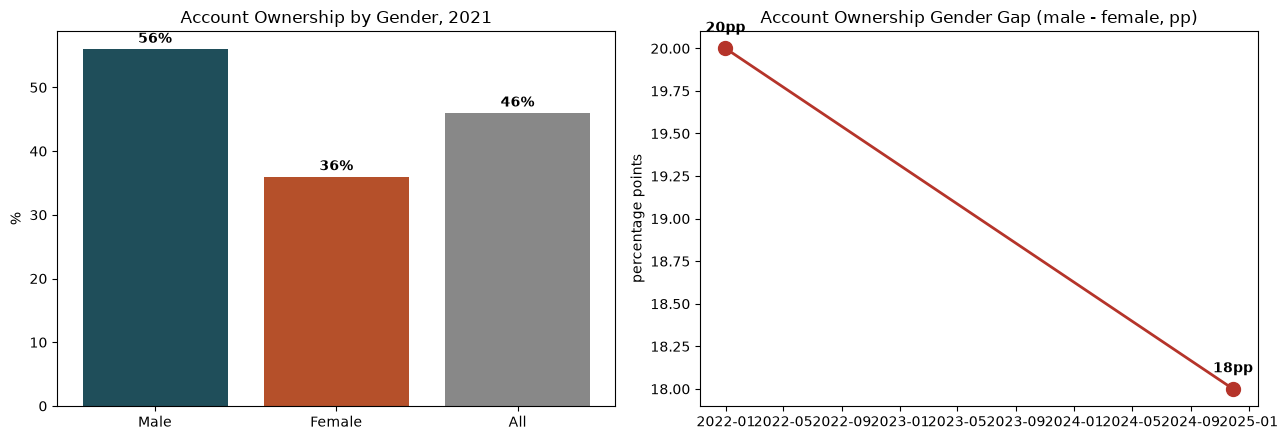

In [8]:
gender_2021 = obs[(obs["indicator_code"] == "ACC_OWNERSHIP") & (obs["observation_date"].dt.year == 2021)]
gap = obs[obs["indicator_code"] == "GEN_GAP_ACC"].sort_values("observation_date")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

g21 = gender_2021.set_index("gender")["value_numeric"]
axes[0].bar(["Male", "Female", "All"], [g21.get("male"), g21.get("female"), g21.get("all")],
            color=["#1F4E5A", "#B5502A", "#888888"])
axes[0].set_title("Account Ownership by Gender, 2021")
axes[0].set_ylabel("%")
for i, v in enumerate([g21.get("male"), g21.get("female"), g21.get("all")]):
    axes[0].text(i, v + 1, f"{v:.0f}%", ha="center", fontweight="bold")

axes[1].plot(gap["observation_date"], gap["value_numeric"], marker="o", markersize=10,
             linewidth=2, color="#B5342A")
for _, row in gap.iterrows():
    axes[1].annotate(f"{row['value_numeric']:.0f}pp", (row["observation_date"], row["value_numeric"]),
                     textcoords="offset points", xytext=(0, 12), ha="center", fontweight="bold")
axes[1].set_title("Account Ownership Gender Gap (male - female, pp)")
axes[1].set_ylabel("percentage points")
plt.tight_layout()
plt.show()

**Gender gap:** in 2021, male ownership (56%) outpaced female ownership (36%) by
20 percentage points. By 2024 the gap had narrowed only slightly, to 18pp — a
2pp improvement in three years. Consistent with this, the **mobile money
awareness gap** (49% male vs. 35% female aware of mobile money, 2023) and the
stark **14% female share of mobile money accounts** (2024) suggest the gender
gap is, if anything, *wider* in the mobile money channel specifically than in
traditional banking overall.

**Urban vs. rural:** no rural/urban disaggregated observations exist in this
dataset — every observation's `location` field is `national`. This is a
genuine data gap (see Data Quality Assessment below), not a finding; we
cannot compare urban/rural ownership with what's currently available.

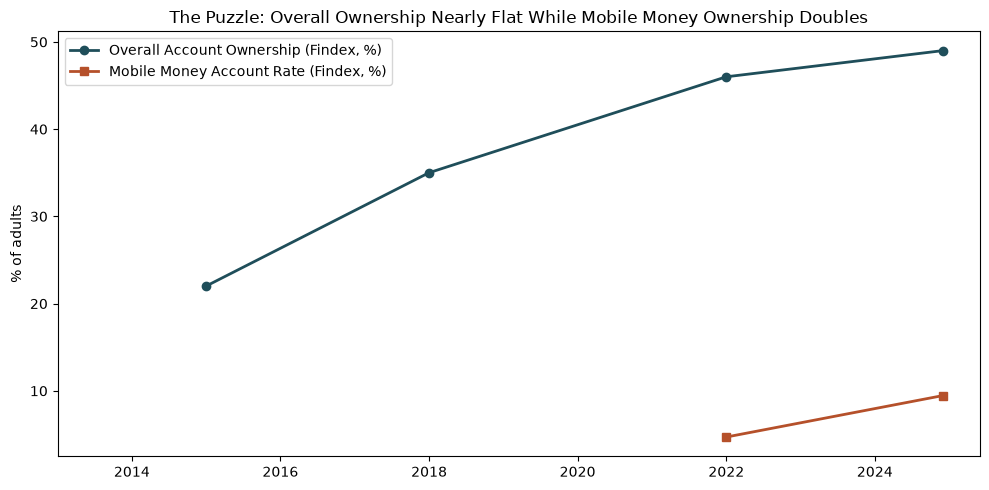

Overall ownership: 46% (2021) -> 49% (2024), +3pp
Mobile money account rate: 4.7% (2021) -> 9.4% (2024), +4.7pp
Telebirr registered users (mid-2025): 54,840,000
M-Pesa registered users (end-2024): 10,800,000
Combined registered mobile money users: 65,640,000


In [9]:
mm_account = obs[obs["indicator_code"] == "ACC_MM_ACCOUNT"].sort_values("observation_date")
telebirr_users = obs[obs["indicator_code"] == "USG_TELEBIRR_USERS"]
mpesa_users = obs[obs["indicator_code"] == "USG_MPESA_USERS"]

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(ownership["observation_date"], ownership["value_numeric"], marker="o", color="#1F4E5A",
         linewidth=2, label="Overall Account Ownership (Findex, %)")
ax1.plot(mm_account["observation_date"], mm_account["value_numeric"], marker="s", color="#B5502A",
         linewidth=2, label="Mobile Money Account Rate (Findex, %)")
ax1.set_ylabel("% of adults")
ax1.set_xlim(pd.Timestamp("2013-01-01"), pd.Timestamp("2025-06-01"))
ax1.legend(loc="upper left")
ax1.set_title("The Puzzle: Overall Ownership Nearly Flat While Mobile Money Ownership Doubles")
plt.tight_layout()
plt.show()

print(f"Overall ownership: {ownership.iloc[-2]['value_numeric']:.0f}% (2021) -> {ownership.iloc[-1]['value_numeric']:.0f}% (2024), +{ownership.iloc[-1]['value_numeric']-ownership.iloc[-2]['value_numeric']:.0f}pp")
print(f"Mobile money account rate: {mm_account.iloc[0]['value_numeric']:.1f}% (2021) -> {mm_account.iloc[1]['value_numeric']:.1f}% (2024), +{mm_account.iloc[1]['value_numeric']-mm_account.iloc[0]['value_numeric']:.1f}pp")
print(f"Telebirr registered users (mid-2025): {telebirr_users['value_numeric'].iloc[0]:,.0f}")
print(f"M-Pesa registered users (end-2024): {mpesa_users['value_numeric'].iloc[0]:,.0f}")
print(f"Combined registered mobile money users: {telebirr_users['value_numeric'].iloc[0] + mpesa_users['value_numeric'].iloc[0]:,.0f}")

**Investigating the 2021-2024 slowdown — this is the central puzzle of the
whole dataset.** Telebirr and M-Pesa together report **~65.6 million
registered mobile-money users** as of their latest counts, in a country of
roughly 70-75 million adults — implying near-universal registration. Yet:

- Findex's own **mobile money account rate** rose only from 4.7% to 9.45% of
  adults (2021-2024) — nowhere near what 65M+ registrations would suggest.
- **Overall** account ownership (which should include mobile money accounts)
  grew just +3pp in the same window.

Three plausible, non-exclusive explanations (hypotheses, not proven):
1. **Registration != ownership.** Telebirr auto-provisions a wallet for many
   SIM purchases; a person can be "registered" without ever considering
   themselves to "have an account" when asked in a household survey.
2. **Duplicate/overlapping registrations.** The same person may hold a
   Telebirr account, an M-Pesa account, and a bank account simultaneously —
   65M+ *registrations* could represent far fewer *unique* included adults.
3. **Low activity.** The Mobile Money Activity Rate (66%, 2024) and M-Pesa's
   own 90-day active rate (7.1M active / 10.8M registered = 66%) show that
   roughly a third of registered accounts are inactive at any time — "usage"
   figures based on registration substantially overstate genuine, sustained
   inclusion.

## 3. Usage (Digital Payments) Analysis

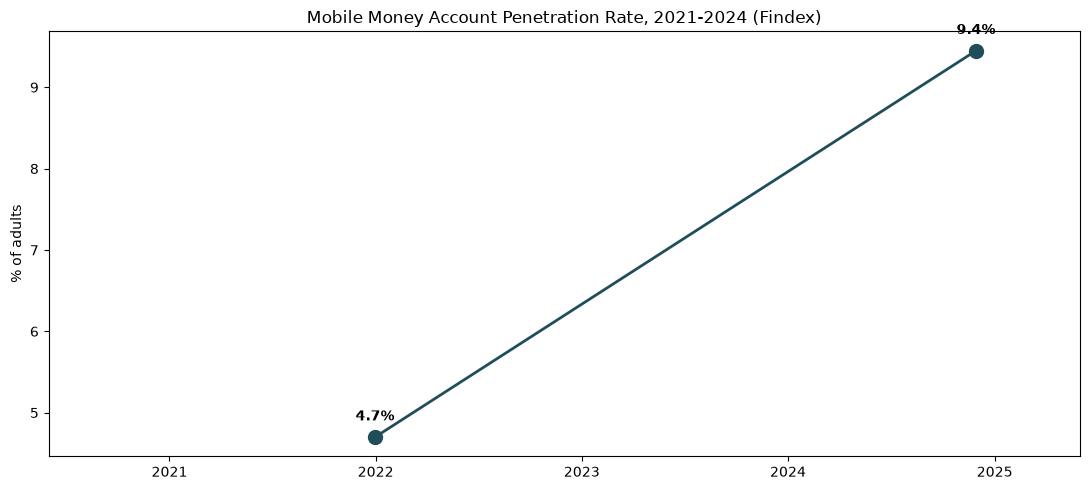

Only 2 Findex survey points exist for this indicator (2021, 2024) -- true 2014-era
mobile money penetration cannot be shown; mobile money barely existed in Ethiopia before Telebirr (2021).


In [10]:
fig, ax = plt.subplots()
ax.plot(mm_account["observation_date"], mm_account["value_numeric"], marker="o", markersize=10,
        linewidth=2, color="#1F4E5A")
for _, row in mm_account.iterrows():
    ax.annotate(f"{row['value_numeric']:.1f}%", (row["observation_date"], row["value_numeric"]),
                textcoords="offset points", xytext=(0, 12), ha="center", fontweight="bold")
ax.set_title("Mobile Money Account Penetration Rate, 2021-2024 (Findex)")
ax.set_ylabel("% of adults")
ax.set_xlim(pd.Timestamp("2020-06-01"), pd.Timestamp("2025-06-01"))
plt.tight_layout()
plt.show()
print("Only 2 Findex survey points exist for this indicator (2021, 2024) -- true 2014-era")
print("mobile money penetration cannot be shown; mobile money barely existed in Ethiopia before Telebirr (2021).")

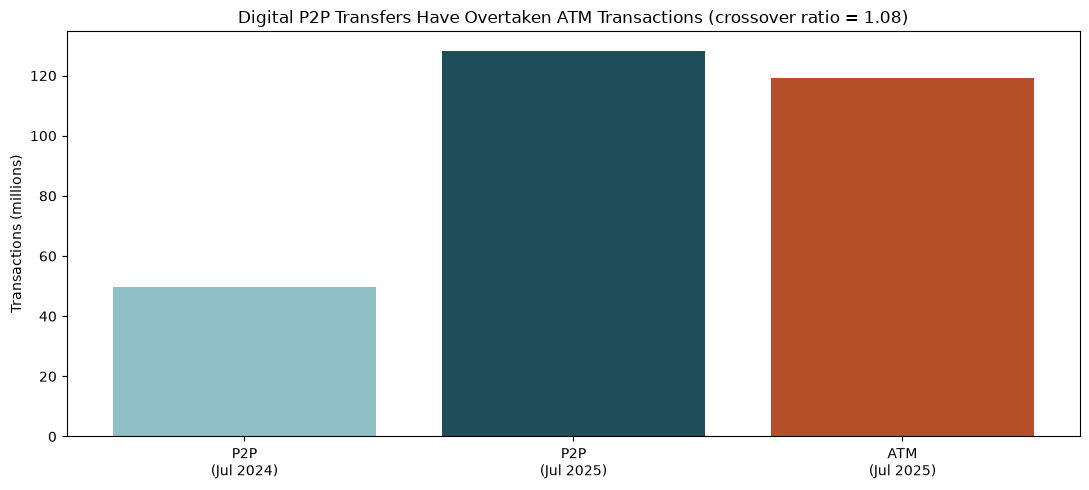

P2P transaction count grew 158% in the year to Jul 2025 (matches EVT_0006: 'P2P Transaction Count Surpasses ATM', Oct 2024)


In [11]:
p2p_count = obs[obs["indicator_code"] == "USG_P2P_COUNT"].sort_values("observation_date")
atm_count = obs[obs["indicator_code"] == "USG_ATM_COUNT"]
crossover = obs[obs["indicator_code"] == "USG_CROSSOVER"]

fig, ax = plt.subplots()
ax.bar(["P2P\n(Jul 2024)", "P2P\n(Jul 2025)", "ATM\n(Jul 2025)"],
       [p2p_count.iloc[0]["value_numeric"]/1e6, p2p_count.iloc[1]["value_numeric"]/1e6, atm_count.iloc[0]["value_numeric"]/1e6],
       color=["#8FBFC7", "#1F4E5A", "#B5502A"])
ax.set_ylabel("Transactions (millions)")
ax.set_title(f"Digital P2P Transfers Have Overtaken ATM Transactions "
             f"(crossover ratio = {crossover.iloc[0]['value_numeric']:.2f})")
plt.tight_layout()
plt.show()
print(f"P2P transaction count grew {(p2p_count.iloc[1]['value_numeric']/p2p_count.iloc[0]['value_numeric']-1):.0%} "
      f"in the year to Jul 2025 (matches EVT_0006: 'P2P Transaction Count Surpasses ATM', Oct 2024)")

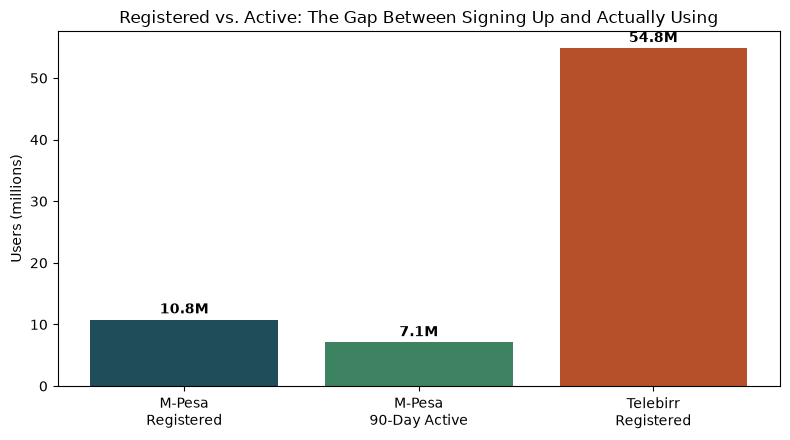

M-Pesa's own registered-to-90-day-active rate: 66%
Aggregate Mobile Money Activity Rate (all providers, 2024): 66%
Telebirr's own reported weekly-active rate (per REC_0035 notes): ~20% -- lower than M-Pesa's 90-day active rate,
but the two aren't directly comparable (different active-window definitions: 7-day vs 90-day).


In [12]:
# Registered vs. active gap
labels = ["M-Pesa\nRegistered", "M-Pesa\n90-Day Active", "Telebirr\nRegistered"]
values = [mpesa_users["value_numeric"].iloc[0], obs[obs['indicator_code']=='USG_MPESA_ACTIVE']["value_numeric"].iloc[0],
          telebirr_users["value_numeric"].iloc[0]]
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(labels, [v/1e6 for v in values], color=["#1F4E5A", "#3D8361", "#B5502A"])
ax.set_ylabel("Users (millions)")
ax.set_title("Registered vs. Active: The Gap Between Signing Up and Actually Using")
for bar, v in zip(bars, values):
    ax.text(bar.get_x()+bar.get_width()/2, v/1e6 + 1, f"{v/1e6:.1f}M", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

active_rate = obs[obs['indicator_code']=='USG_MPESA_ACTIVE']['value_numeric'].iloc[0] / mpesa_users['value_numeric'].iloc[0]
print(f"M-Pesa's own registered-to-90-day-active rate: {active_rate:.0%}")
print(f"Aggregate Mobile Money Activity Rate (all providers, 2024): "
      f"{obs[obs['indicator_code']=='USG_ACTIVE_RATE']['value_numeric'].iloc[0]:.0f}%")
print("Telebirr's own reported weekly-active rate (per REC_0035 notes): ~20% -- lower than M-Pesa's 90-day active rate,")
print("but the two aren't directly comparable (different active-window definitions: 7-day vs 90-day).")

**Registered vs. active gap, quantified:** M-Pesa converts registered users
to 90-day active users at about 66% — meaning roughly a third of registered
M-Pesa accounts show no activity in a 3-month window. Telebirr's own reported
active rate (~20%, but measured weekly rather than over 90 days) suggests an
even larger share of its 54.8 million "registered users" are not meaningfully
engaged day-to-day. This is a first-order reason why registration counts
(65M+) vastly overstate genuine usage, and by extension, why survey-measured
account *ownership* (which presumably requires the respondent to consider the
account theirs and know about it) lags registration figures so dramatically.

**Payment use cases:** P2P transfers are the dataset's best-covered use case
(2 data points, showing +158% growth in one year) and have now overtaken ATM
transactions in volume (crossover ratio 1.08). No observations exist for
merchant payments, bill pay, or wage disbursement specifically — these use
cases are a data gap, though Telebirr's microloan product (REC_0038) hints
at credit as an emerging use case beyond simple transfers.

## 4. Infrastructure and Enablers

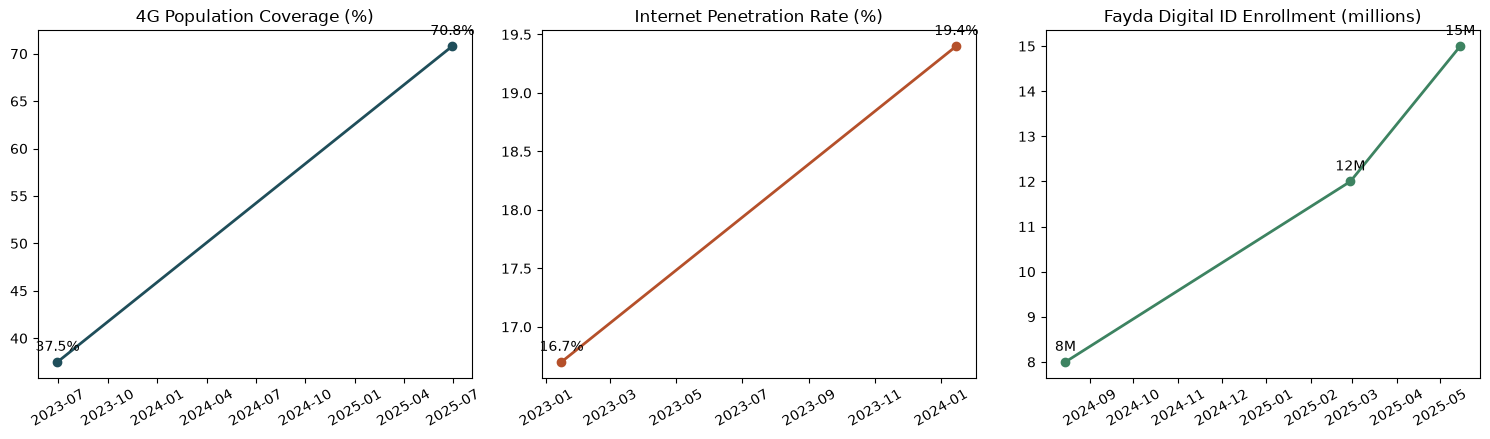

In [13]:
cov_4g = obs[obs["indicator_code"] == "ACC_4G_COV"].sort_values("observation_date")
internet_pen = obs[obs["indicator_code"] == "ACC_INTERNET_PEN"].sort_values("observation_date")
fayda = obs[obs["indicator_code"] == "ACC_FAYDA"].sort_values("observation_date")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].plot(cov_4g["observation_date"], cov_4g["value_numeric"], marker="o", color="#1F4E5A", linewidth=2)
axes[0].set_title("4G Population Coverage (%)")
for _, row in cov_4g.iterrows():
    axes[0].annotate(f"{row['value_numeric']:.1f}%", (row["observation_date"], row["value_numeric"]), xytext=(0,8), textcoords="offset points", ha="center")

axes[1].plot(internet_pen["observation_date"], internet_pen["value_numeric"], marker="o", color="#B5502A", linewidth=2)
axes[1].set_title("Internet Penetration Rate (%)")
for _, row in internet_pen.iterrows():
    axes[1].annotate(f"{row['value_numeric']:.1f}%", (row["observation_date"], row["value_numeric"]), xytext=(0,8), textcoords="offset points", ha="center")

axes[2].plot(fayda["observation_date"], fayda["value_numeric"]/1e6, marker="o", color="#3D8361", linewidth=2)
axes[2].set_title("Fayda Digital ID Enrollment (millions)")
for _, row in fayda.iterrows():
    axes[2].annotate(f"{row['value_numeric']/1e6:.0f}M", (row["observation_date"], row["value_numeric"]/1e6), xytext=(0,8), textcoords="offset points", ha="center")

for ax in axes:
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

**Infrastructure is scaling much faster than usage or ownership outcomes:**
4G coverage nearly doubled (37.5% -> 70.8%) in two years, Fayda digital ID
enrollment grew from 8M to 15M (+87%) in nine months, yet account ownership
grew only 3pp and internet penetration crept from 16.7% to 19.4%. This gap
between *supply-side infrastructure* and *demand-side outcomes* is itself a
finding: coverage and connectivity are being built faster than they are
converting into measured financial inclusion, consistent with the
registration-vs-usage gap found in Section 3.

**Potential leading indicators for Findex outcomes:** given the lag between
infrastructure rollout and survey-measured outcomes (Findex is only fielded
every ~3 years), 4G coverage, internet penetration, and Fayda ID enrollment
are all plausible *leading* indicators — each is measured far more frequently
than Findex itself, and each has a theorized (if not yet empirically proven
in this dataset) causal path to account ownership and usage. The existing
impact_links already encode some of this: `IMP_0004` links Safaricom's entry
to 4G coverage, and `IMP_0008` links the Fayda ID rollout to account
ownership with a comparable-country citation (India's Aadhaar/Jan Dhan
experience).

## 5. Event Timeline and Visual Analysis

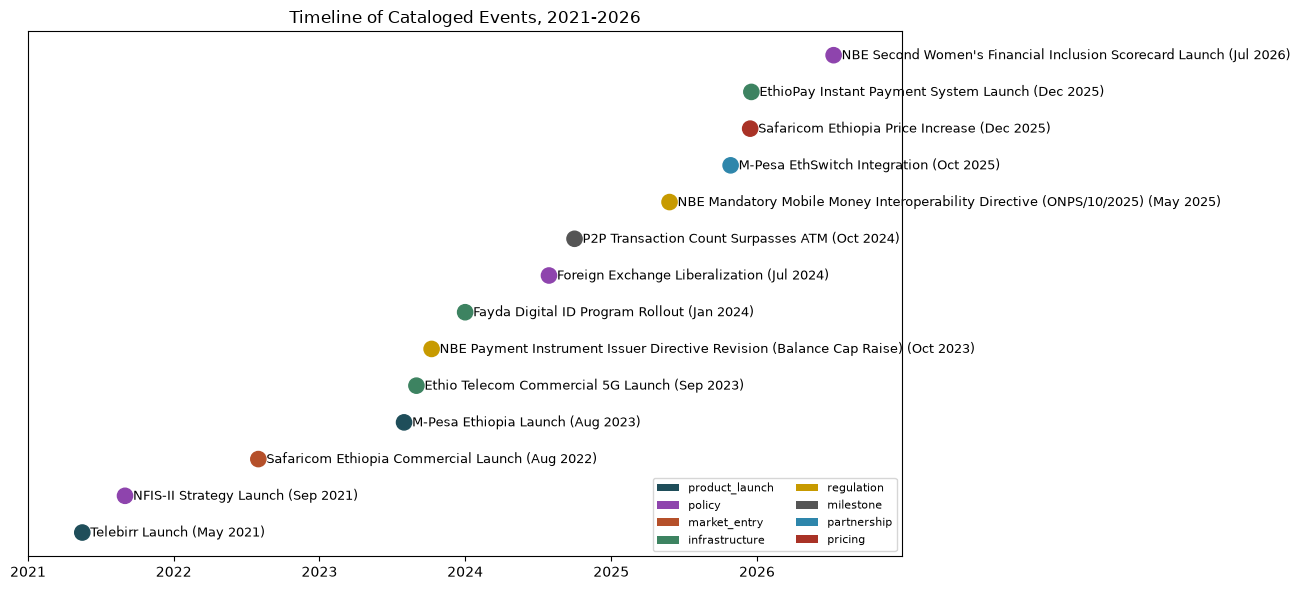

In [14]:
category_colors = {
    "product_launch": "#1F4E5A", "policy": "#8E44AD", "market_entry": "#B5502A",
    "infrastructure": "#3D8361", "regulation": "#C79A00", "milestone": "#555555",
    "partnership": "#2E86AB", "pricing": "#A93226",
}

fig, ax = plt.subplots(figsize=(13, 6))
y_positions = range(len(events))
colors = [category_colors.get(cat, "#999999") for cat in events["category"]]
ax.scatter(events["observation_date"], y_positions, c=colors, s=120, zorder=3)
for y, (_, row) in zip(y_positions, events.iterrows()):
    ax.text(row["observation_date"], y, f"  {row['indicator']} ({row['observation_date'].strftime('%b %Y')})",
            va="center", fontsize=9)
ax.set_yticks([])
ax.set_xlim(pd.Timestamp("2021-01-01"), pd.Timestamp("2026-12-31"))
ax.set_title("Timeline of Cataloged Events, 2021-2026")
legend_elements = [Patch(facecolor=c, label=cat) for cat, c in category_colors.items() if cat in events["category"].unique()]
ax.legend(handles=legend_elements, loc="lower right", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

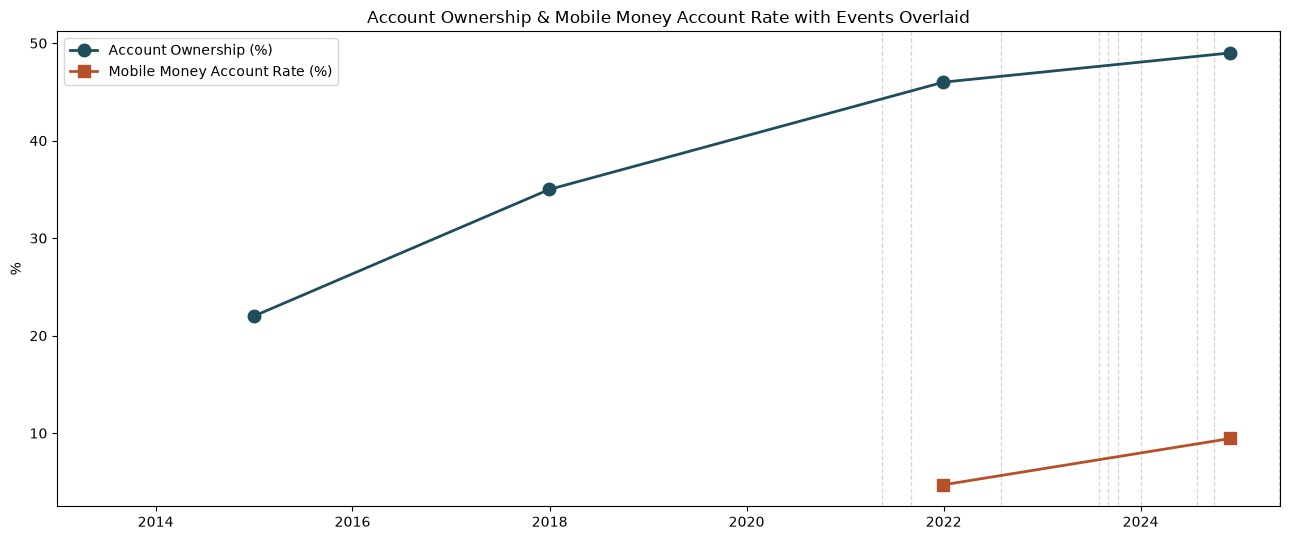

In [15]:
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(ownership["observation_date"], ownership["value_numeric"], marker="o", markersize=9,
        linewidth=2, color="#1F4E5A", label="Account Ownership (%)", zorder=3)
ax.plot(mm_account["observation_date"], mm_account["value_numeric"], marker="s", markersize=9,
        linewidth=2, color="#B5502A", label="Mobile Money Account Rate (%)", zorder=3)

for _, row in events.iterrows():
    ax.axvline(row["observation_date"], color="#999999", alpha=0.4, linestyle="--", linewidth=0.9, zorder=1)

key_events = {
    "EVT_0001": "Telebirr\nlaunch",
    "EVT_0002": "Safaricom\nentry",
    "EVT_0003": "M-Pesa\nlaunch",
}
for eid, label in key_events.items():
    d = events.loc[events["record_id"] == eid, "observation_date"].iloc[0]
    ax.annotate(label, (d, 2), fontsize=8, ha="center", color="#B5502A", fontweight="bold")

ax.set_xlim(pd.Timestamp("2013-01-01"), pd.Timestamp("2025-06-01"))
ax.set_ylabel("%")
ax.set_title("Account Ownership & Mobile Money Account Rate with Events Overlaid")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

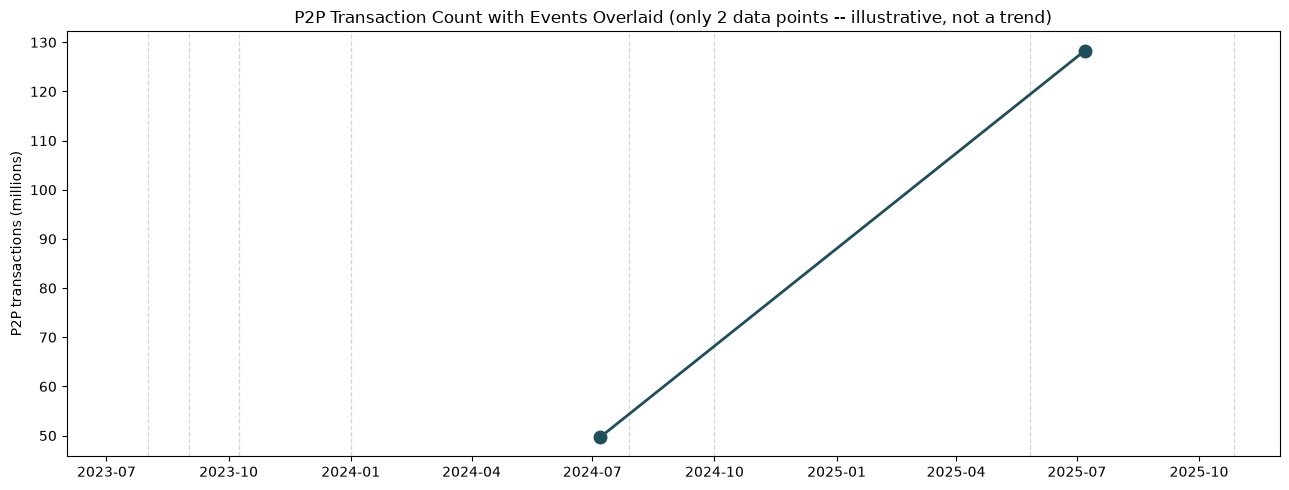

In [16]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(p2p_count["observation_date"], p2p_count["value_numeric"]/1e6, marker="o", markersize=9,
        linewidth=2, color="#1F4E5A", zorder=3)
for _, row in events.iterrows():
    ax.axvline(row["observation_date"], color="#999999", alpha=0.4, linestyle="--", linewidth=0.9, zorder=1)
ax.set_xlim(pd.Timestamp("2023-06-01"), pd.Timestamp("2025-12-01"))
ax.set_ylabel("P2P transactions (millions)")
ax.set_title("P2P Transaction Count with Events Overlaid (only 2 data points -- illustrative, not a trend)")
plt.tight_layout()
plt.show()

**Visually assessing the three specific questions asked:**

- **Did account ownership accelerate after Telebirr's launch (May 2021)?**
  No — descriptively, the opposite. The 2021 Findex wave was fielded in the
  same year as the launch (too early to reflect it), and the *next* wave
  (2024) shows the **slowest** growth of the three survey intervals (+1pp/yr,
  vs. +2.75pp/yr in the prior period). Telebirr's own registered-user count
  did grow enormously in this window, but that growth did not show up in
  Findex's account-ownership measure at anywhere near the same scale — the
  central puzzle from Section 2.
- **Did mobile money accounts grow after M-Pesa's entry (Aug 2023)?** We
  cannot show a within-M-Pesa "before/after" comparison — M-Pesa's own
  registered/active user figures exist only as single snapshots (Dec 2024),
  with no pre-launch baseline (trivially zero) or repeated post-launch
  readings. The market-wide Mobile Money Account Rate's second Findex point
  (9.45%, Nov 2024) *does* postdate M-Pesa's launch and is higher than the
  2021 figure, consistent with growth, but with only two points spanning a
  period containing *two* major launches (Telebirr and M-Pesa) plus a
  regulatory change (EVT_0011), the data cannot isolate M-Pesa's specific
  contribution.
- **What happened around Safaricom's market entry (Aug 2022)?** No
  indicator has an observation immediately bracketing this date — the
  nearest 4G coverage reading is 10 months later (Jun 2023, 37.5%). We can
  only note the existing impact_link's hypothesis (`IMP_0004`: Safaricom
  entry -> increased 4G coverage, empirical, 12-month lag) rather than
  independently confirm it with before/after observations of our own.

**A consistent theme:** this dataset's temporal resolution (mostly single
annual/multi-year snapshots) is fundamentally too coarse to visually confirm
or refute "did X accelerate after Y" questions with confidence — a limitation
carried through to the Data Quality Assessment below.

## 6. Correlation Analysis

**A note on method before the numbers:** with most indicators having only
1-4 observations at irregular, non-aligned dates, a conventional Pearson
correlation matrix across raw indicator values would be built on 2-4 point
"series" sampled at different times for different indicators — any
correlation coefficient computed this way would be a statistical artifact,
not a real relationship (a line always "fits" 2 points perfectly). Rather
than produce a misleadingly precise-looking correlation matrix, this section
does two more defensible things instead: (1) a small, clearly-caveated
year-aligned comparison of the few indicators that *do* have multiple points
in overlapping years, and (2) a systematic synthesis of the `impact_links`
table itself, which is literally the dataset's own encoding of believed
relationships -- exactly what Task 2 instruction 6 asks us to examine.

In [19]:
# (1) Illustrative year-aligned comparison -- explicitly caveated, not a formal correlation
annual = obs[obs["indicator_code"].isin(["ACC_4G_COV", "ACC_INTERNET_PEN", "ACC_MM_ACCOUNT", "ACC_OWNERSHIP"])].copy()
annual["year"] = annual["observation_date"].dt.year
pivot = annual[annual["gender"] == "all"].pivot_table(index="year", columns="indicator_code", values="value_numeric")
print(pivot)
print()
print("Only 1-2 overlapping years exist per pair -- a numeric correlation coefficient")
print("from this table would not be statistically meaningful and is deliberately not computed.")

indicator_code  ACC_4G_COV  ACC_INTERNET_PEN  ACC_MM_ACCOUNT  ACC_OWNERSHIP
year                                                                       
2014                   NaN               NaN             NaN           22.0
2017                   NaN               NaN             NaN           35.0
2021                   NaN               NaN            4.70           46.0
2023                  37.5              16.7             NaN            NaN
2024                   NaN              19.4            9.45           49.0
2025                  70.8               NaN             NaN            NaN

Only 1-2 overlapping years exist per pair -- a numeric correlation coefficient
from this table would not be statistically meaningful and is deliberately not computed.


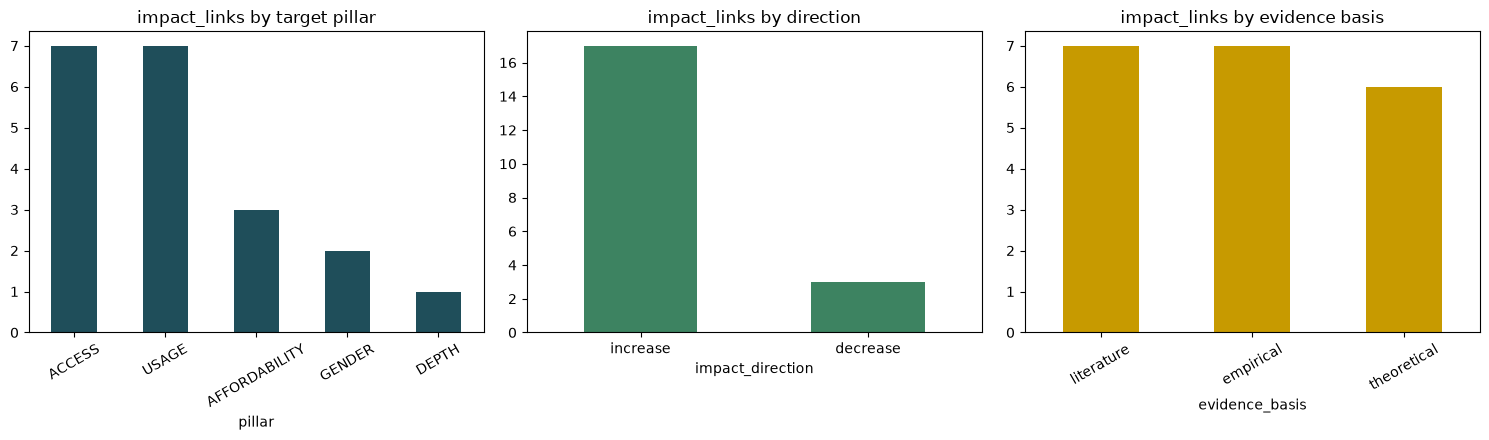

In [20]:
# (2) Systematic synthesis of impact_links: what does the dataset itself believe drives what?
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

links["pillar"].value_counts().plot(kind="bar", ax=axes[0], color="#1F4E5A")
axes[0].set_title("impact_links by target pillar")
axes[0].tick_params(axis="x", rotation=30)

links["impact_direction"].value_counts().plot(kind="bar", ax=axes[1], color="#3D8361")
axes[1].set_title("impact_links by direction")
axes[1].tick_params(axis="x", rotation=0)

links["evidence_basis"].value_counts().plot(kind="bar", ax=axes[2], color="#C79A00")
axes[2].set_title("impact_links by evidence basis")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [21]:
print("Which indicators are targeted by the most impact_links (i.e. believed to be")
print("influenced by the most distinct events)?\n")
print(links["related_indicator"].value_counts())
print()
print("Which pillars receive 'increase' vs 'decrease' links?")
print(links.groupby(["pillar", "impact_direction"]).size().unstack(fill_value=0))

Which indicators are targeted by the most impact_links (i.e. believed to be
influenced by the most distinct events)?

related_indicator
USG_P2P_COUNT           3
AFF_DATA_INCOME         3
ACC_OWNERSHIP           2
ACC_MM_ACCOUNT          2
GEN_GAP_ACC             2
USG_TELEBIRR_USERS      1
ACC_4G_COV              1
USG_MPESA_USERS         1
USG_MPESA_ACTIVE        1
USG_TELEBIRR_VALUE      1
ACC_INTERNET_PEN        1
DEPTH_TELEBIRR_LOANS    1
ACC_MM_AGENTS           1
Name: count, dtype: int64

Which pillars receive 'increase' vs 'decrease' links?
impact_direction  decrease  increase
pillar                              
ACCESS                   0         7
AFFORDABILITY            1         2
DEPTH                    0         1
GENDER                   2         0
USAGE                    0         7


**Which factors appear most strongly associated with Access?** By count of
impact_links, `ACC_OWNERSHIP` and `ACC_MM_ACCOUNT` are each targeted by 2
links -- driven by Telebirr's launch, the Fayda ID rollout, M-Pesa's launch,
and the 2025 interoperability mandate. This converges with Section 4's
infrastructure findings: ID enrollment and mobile money product launches are
among the dataset's most-cited *believed* drivers of account ownership, even
though Section 2 showed the actual Findex-measured effect on ownership has
been modest so far.

**Which factors appear most strongly associated with Usage?** `USG_P2P_COUNT`
is the single most-targeted indicator in the entire impact_links table (3
links, from Telebirr's launch, M-Pesa's EthSwitch integration, and the
EthioPay launch) -- consistent with P2P transfers being the dataset's
best-evidenced, fastest-growing usage metric (Section 3). Interestingly,
`AFF_DATA_INCOME` (data affordability) is *equally* well-linked (3 links),
suggesting the dataset's own model treats data costs as just as central to
digital usage as any single product launch.

**What insights emerge from the impact_links records themselves?** Of 20
total links, 6 (30%) rest on `theoretical` reasoning rather than
Ethiopia-specific `empirical` evidence (7, 35%) or cross-country `literature`
(7, 35%) -- meaning almost a third of this dataset's own model of "what
drives what" is, by its own admission, a hypothesis rather than a
demonstrated fact. This share roughly doubled with enrichment: the starter
data's own 14 links were only 1 theoretical (7%), while 5 of our 6 new links
were necessarily marked theoretical (new events are, by definition, too
recent to have empirical Ethiopian outcome data yet). Any downstream
impact-modeling work should weight `empirical` links more heavily than
`theoretical` ones, and should treat comparable-country citations (Kenya,
Tanzania, India, Rwanda) as suggestive, not proof, for Ethiopia specifically.
Almost all links (17 of 20, 85%) point in an `increase` direction -- only 3
model a `decrease` (all narrowing the AFF_DATA_INCOME cost or the GEN_GAP_ACC
gender gap), which is worth keeping in mind: this dataset currently has much
more to say about what grows inclusion than about what could set it back.

## 7. Key Insights and Data Quality Assessment

### Key Insights (with supporting evidence)

**1. Account ownership growth has decelerated sharply, from +4.33pp/year
(2014-2017) to +1.00pp/year (2021-2024) — a ~4x slowdown — despite this being
the exact window of Ethiopia's mobile money boom.** (Section 2; Findex
REC_0001-REC_0003, REC_0006)

**2. Registered mobile money accounts (~65.6 million combined, Telebirr +
M-Pesa) vastly exceed both Findex-measured mobile money ownership (9.45% of
adults, ~2024) and plausible active usage (roughly two-thirds active at any
time) — registration counts overstate genuine financial inclusion by a wide
margin, likely due to auto-provisioned wallets, duplicate registrations
across providers, and low activity rates.** (Section 2-3; REC_0007/REC_0008,
REC_0021, REC_0023/REC_0024, REC_0025)

**3. The gender gap in account ownership narrowed only marginally (20pp -> 18pp,
2021-2024), and is markedly worse in the mobile money channel specifically —
women hold only 14% of mobile money accounts and report 14pp lower mobile
money awareness than men — suggesting mobile money is currently amplifying,
not closing, the existing gender gap.** (Section 2; REC_0027/REC_0028,
REC_0029, REC_0036/REC_0037)

**4. Supply-side infrastructure (4G coverage, digital ID enrollment) is
scaling far faster than demand-side outcomes: 4G coverage nearly doubled in
two years and Fayda ID enrollment grew 87% in nine months, while account
ownership grew only 3pp and internet penetration crept up by less than 3pp
per year over the same broad period.** (Section 4; REC_0009/REC_0010,
REC_0012-REC_0014, REC_0039/REC_0040)

**5. Nearly a third (6 of 20, 30%) of the dataset's own modeled
event-to-indicator relationships (impact_links) rest on theoretical reasoning
rather than Ethiopia-specific empirical evidence, and the dataset's temporal
resolution (mostly single annual/multi-year snapshots) is too coarse to
visually confirm whether any of the three major product launches (Telebirr,
Safaricom, M-Pesa) actually accelerated the indicators they targeted.**
(Section 5-6; full impact_links table, event timeline)

### Data Quality Assessment

**Coverage gaps:**
- **QUALITY and TRUST pillars have zero observations** — service reliability,
  complaint rates, and fraud/trust metrics are entirely unmeasured.
- **AFFORDABILITY and DEPTH pillars have exactly one observation each** —
  essentially single reference points, not trends.
- **No rural/urban disaggregation exists anywhere in the dataset** — every
  observation's `location` field reads `national`. Given Ethiopia's large
  rural population share, this is arguably the single biggest gap limiting
  this analysis, since urban/rural gaps are frequently as large as gender
  gaps in comparable markets.
- **No merchant-payment, bill-pay, or wage-disbursement use-case data** —
  only P2P transfers and ATM activity are measured on the usage side.

**Confidence and source-type composition:**
- 76% of all records are `high` confidence, but this reflects source
  reliability, not analytical sufficiency — many high-confidence indicators
  still have only 1-2 total observations.
- The enrichment additions (Task 1) are deliberately capped at `medium`
  confidence throughout, since they rely on secondary aggregators
  (DataReportal, GSMA/FSD Ethiopia reports, one news source for a regulatory
  directive) rather than primary Ethiopian government statistical releases,
  except where an NBE press release was used directly.

**A genuine data-entry error found during this analysis:** `REC_0006` (the
critical 2024 Findex account-ownership observation, 49%) has its
`comparable_country`, `collected_by`, `collection_date`, and `notes` fields
shifted by one column in the **original starter data** -- `collected_by`
contains a date, `collection_date` contains free text that belongs in
`notes`, etc. The core measured value (49%, ACC_OWNERSHIP, 2024-11-29,
Global Findex 2024) is intact and was used as-is throughout this analysis;
only the provenance metadata is affected. `src/data_loader.py` was hardened
(see git history) to degrade this kind of bad cell to a missing value
instead of crashing the whole pipeline, and a regression test
(`test_date_parsing_survives_column_shifted_rows`) now guards against it
silently reappearing.

**Temporal resolution mismatch:** Findex-style survey indicators (account
ownership, mobile money account rate) are measured every 3 years; operator
and regulator indicators (4G coverage, registered users, transaction counts)
are measured far more often but only recently (2023 onward) and inconsistently
across providers. This makes it structurally difficult to line up a
"leading indicator" with the survey outcome it's supposed to predict.

### Hypotheses for the impact modeling phase

1. Registration-based usage metrics (registered users, transaction counts)
   systematically overstate genuine financial inclusion relative to
   survey-measured ownership/usage -- an impact model should weight or
   discount registration-based indicators accordingly, or explicitly model
   an "activity rate" adjustment.
2. The account-ownership gender gap responds more to product design and
   targeted programs (e.g., the NBE Women's Financial Inclusion Scorecard)
   than to broad infrastructure rollouts -- infrastructure metrics (4G,
   Fayda ID) show no evidence yet of narrowing the gender gap.
3. Regulatory changes (balance cap raises, interoperability mandates) may
   act with a longer lag on *usage value* (transaction size/volume) than on
   *account registration* -- worth testing lag structures separately for
   registration-type vs. value-type outcomes.
4. Given the coarse Findex survey cadence, higher-frequency proxies (4G
   coverage, Fayda ID enrollment, P2P transaction counts) may be more useful
   *leading* indicators for the impact-modeling phase than waiting for the
   next Findex wave.